In [1]:
%load_ext autoreload
%autoreload 2

import util as yu
from util import *
import util_moments as yum

# yu.setpath('check_helicity_priyajit')

projs=['P0', 'Px', 'Py', 'Pz']
inserts=['tt', 'tx', 'ty', 'tz', 'xx', 'xy', 'xz', 'yy', 'yz', 'zz']
enss=['b']
ens='b'

In [2]:
path=f'pkl/analysis_c2pt/reg_ignore/ens2pars_jk_meffnst_selected.pkl'
[ens2pars_jk_meff1st,ens2pars_jk_meff2st,ens2pars_jk_meff3st]=yu.load_pkl(path)

In [3]:
ens2c2pt={}; ens2moms_2pt={}; ens2c2pt0={}; ens2Njk={}
for ens in enss:
    basepath=f'/p/project1/ngff/li47/code/projectData/05_moments/{yu.ens2full[ens]}/data_merge/'
    path=f'{basepath}disc_2pt.h5'
    with h5py.File(path) as f:
        moms_2pt=yu.moms2list(f['moms'])
        c2pt=yu.jackknife(np.real(f['data/N_N'][:,:,:]))
        
    ens2moms_2pt[ens]=moms_2pt
    ens2c2pt[ens]=c2pt
    ens2c2pt0[ens]=c2pt[:,:,moms_2pt.index([0,0,0])]
    ens2Njk[ens]=len(c2pt)

In [4]:
path='/p/project1/ngff/li47/code/scratch/run/05_moments_run5_1DA/cB211.072.64/data_merge/disc_0,0,0,0,0,0.h5'
yu.print_hdf5_structure(path)

/: 1 groups, ['data']; 4 datasets, ['cfgs', 'inserts', 'moms', 'notes']; 
cfgs: (725,)
inserts=['tt', 'tx', 'ty', 'tz', 'xx', 'xy', 'xz', 'yy', 'yz', 'zz']
moms: (1, 6)
notes=['time,mom,proj,insert', 'mom=[sink,ins]; sink+ins=src', 'proj=[P0,Px,Py,Pz]', 'adding an additional dimension [cfg] in the beginning']
/data: 63 datasets, ['j+;disc_10', 'j+;disc_11', 'j+;disc_12', 'j+;disc_13']; 
j+;disc_10: (725, 11, 1, 4, 10)


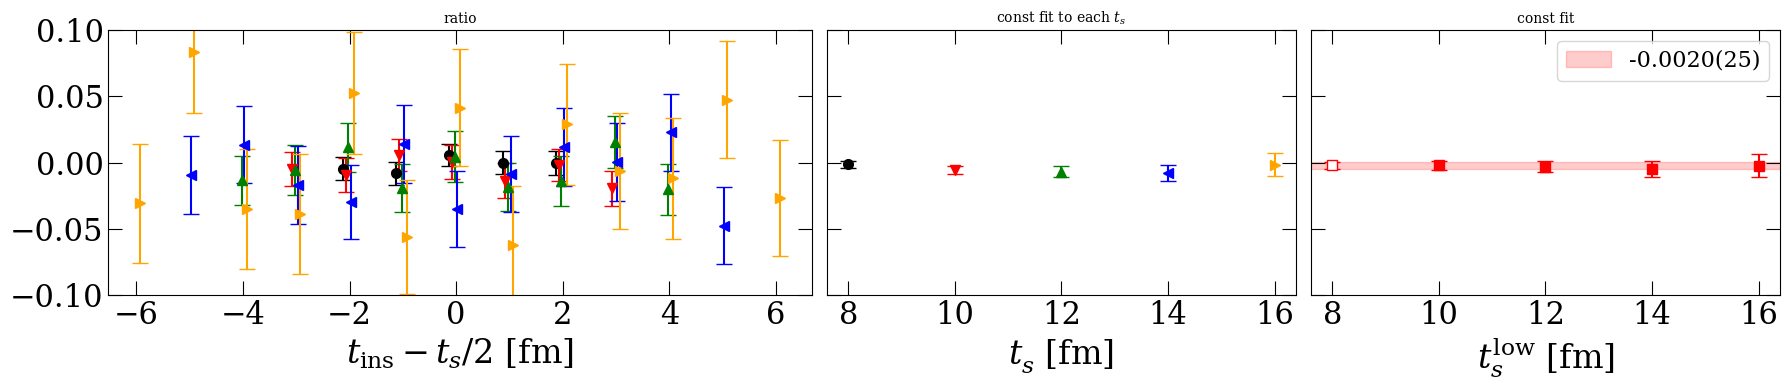

In [15]:
path='/p/project1/ngff/li47/code/scratch/run/05_moments_run5_1DA/cB211.072.64/data_merge/disc_0,0,0,0,0,0.h5'

factor=-1j * ens2pars_jk_meff2st[ens][:,0]/2

c2pt=ens2c2pt0[ens]

tfs=np.arange(8,22,2)
tf2ratio={}
with h5py.File(path) as f:
    for tf in tfs:
        t=f[f'data/j+;disc_{tf}'][:]
        t=t[:,:,0,projs.index('Pz'),inserts.index('tz')]
        t=yu.jackknife(np.real(t/factor[:,None]))
        t=t/c2pt[:,tf:tf+1]
        tf2ratio[tf]=t

fits_band=yu.doFits_3pt_band(tf2ratio,[2],corrQ=False)
fits_const=yu.doFits_3pt('const',tf2ratio,[8,10,12,14,16],[3],symmetrizeQ=False,corrQ=True)
# tfmin=gett(0.6); tcmin=gett(0.3)
fit_const_MA=yu.doMA_3pt(fits_const,fitlabels=(8,3))
dic={
    'base:[tf2ratio,fits_band,fits_const,fits_sum,fits_2st]':[tf2ratio,fits_band,fits_const,None,None],
    'WAMA:[fit_band_WA,fit_const_MA,fit_sum_MA,fit_2st_MA]':[None,fit_const_MA,None,None],
    'rainbow:[tfmin,tfmax,tcmin,dt]':[8,16,2,2],
    'fit_band:[tfmin,tfmax,tcmin_min,tcmin_max,dtf,dtc]':[8,16,None,None,2,1],
    'xyunit':[1,1],
}

fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','fit_band','fit_const'],colors_rainbow=['black','r','g','b','orange'])
ax=axs[0,0]
ax.set_ylim([-0.1,0.1])
yu.finalizePlot()

# xcheck Ferenc

In [6]:
path='/p/project1/ngff/pittler/crosschech_helicity/pi_i0xyz_results.h5'
with h5py.File(path) as f:
    print(f['tsep8']['pi_i0z'][:4])
    
path='/p/project1/ngff/li47/code/scratch/run/05_moments_run5_1DA_xcheckFerenc/cB211.072.64/data_avgsrc/a0500/disc_0,0,0,0,0,0.h5'
with h5py.File(path) as f:
    print(f['data/j+;disc_8'][:4,0,projs.index('P0'),inserts.index('tz')])


[-1.47329315e-11+5.74996975e-11j -2.37884604e-11-2.55878591e-11j
 -2.89760009e-10+3.34536818e-11j -2.16704759e-10+6.05604818e-10j]
[-1.47329293e-11+5.74996864e-11j -2.37884672e-11-2.55878446e-11j
 -2.89760007e-10+3.34536794e-11j -2.16704767e-10+6.05604817e-10j]
